In [1]:
import numpy as np
import glob
import os

#Función que lee un archivo .pgm y que devuelve el conteo de píxeles asociados a cada clase
def contar_pixeles_pgm(ruta_archivo):
    try:
        #Abrimos el archivo en modo lectura binaria
        with open(ruta_archivo, 'rb') as f:
            #Comprobamos que el formato sea P5 (binario)
            tipo = f.readline().decode().strip()
            if tipo not in ['P5']:
                return None

            #Saltamos posibles comentarios y líneas vacías
            linea = f.readline().decode()
            while linea.startswith('#') or not linea.strip():
                linea = f.readline().decode()
            
            #Divide la línea para obtener el ancho y el alto
            dimensiones = linea.split()
            #Si el ancho y el alto no se encuentran en la misma línea se sigue leyendo hasta encontrar ambos
            while len(dimensiones) < 2:
                dimensiones += f.readline().decode().split()
            
            #Convertimos el ancho y el alto a enteros
            ancho, alto = map(int, dimensiones[:2])
            
            #Leemos hasta encontrar la línea asociada al valor máximo de gris (la clase máxima)
            linea_max = f.readline().decode().strip()
            while not linea_max or linea_max.startswith('#'):
                linea_max = f.readline().decode().strip()
            max_val = int(linea_max)

            #Decidimos si usar 1 byte por píxel o 2 bytes
            dtype = np.uint8 if max_val < 256 else np.uint16
            #Leemos todos los datos binarios restantes y los convertimos a un array de Numpy
            datos = np.frombuffer(f.read(), dtype=dtype)
            
            #Contamos cuantas veces aparece cada valor (cada clase)
            conteo = np.bincount(datos, minlength=max_val + 1)

            #Devolvemos un diccionario donde la clave es el valor del píxel (la clase) y el valor es el número de píxeles con ese valor y solo se incluyen los valores que aparezcan como mínimo 1 vez
            return {i: int(cantidad) for i, cantidad in enumerate(conteo) if cantidad > 0}

    except Exception as e:
        print(f"Error en {ruta_archivo}: {e}")
        return None



## Comprobación del número de píxeles de cada clase

In [2]:
directorio_base = "datosEntrada"
patron_busqueda = os.path.join(directorio_base, "**", "*.pgm")

#Buscamos de forma recursiva todos los archivos .pgm
archivos_pgm = glob.glob(patron_busqueda, recursive=True)

if not archivos_pgm:
    print(f"No se encontraron archivos .pgm en: {os.path.abspath(directorio_base)}")
else:
    #Imprimimos cuantos archivos .pgm se han encontrado
    print(f"*** Se han encontrado {len(archivos_pgm)} archivos en las subcarpetas ***\n")
    
    #Recorremos todos los archivos
    for archivo in archivos_pgm:
        print(f"ARCHIVO: {archivo}")
        #Contamos los píxeles de cada clase que hay en el archivo .pgm
        resultado = contar_pixeles_pgm(archivo)

        if resultado:
            #Sumamos el total de píxeles que tienen una clase asociada (los que no poseen valor 0)
            total_sin_clase_0 = sum(cant for val, cant in resultado.items() if val != 0)

            #Calculamos el total absoluto de píxeles
            total_absoluto = sum(resultado.values())
            
            #Imprimimos la cabecera de la tabla
            print(f"{'Valor':<10} | {'Cantidad':<15} | {'% (Sin Clase 0)':<10}")
            print("-" * 45)
            
            #Recorremos las clases
            for valor in sorted(resultado.keys()):
                cantidad = resultado[valor]
                
                #Si la clase es 0 se imprime sin su porcentaje
                if valor == 0:
                    print(f"{valor:<10} | {cantidad:<15} | {'(Fondo)':>10}")
                
                #Si la clase no es 0 se imprime con el porcentaje de píxeles clasificados que representa
                else:
                    porcentaje = (cantidad / total_sin_clase_0) * 100
                    print(f"{valor:<10} | {cantidad:<15} | {porcentaje:>9.2f}%")

            
            print("-" * 45)
            print(f"Total píxeles con clase (sin clase 0): {total_sin_clase_0:<10} | {(total_sin_clase_0/total_absoluto)*100:>8.4f} %")
            print(f"Total píxeles sin clase (clase 0): {total_absoluto-total_sin_clase_0:<10} | {((total_absoluto-total_sin_clase_0)/total_absoluto)*100:>8.4f} %")
        else:
            print(f"Error: No se pudo procesar el archivo.")
        
        print("\n" + "="*50 + "\n")

*** Se han encontrado 8 archivos en las subcarpetas ***

ARCHIVO: datosEntrada/oitaven/oitaven_river.pgm
Valor      | Cantidad        | % (Sin Clase 0)
---------------------------------------------
0          | 38896279        |    (Fondo)
1          | 309248          |      5.10%
2          | 113324          |      1.87%
3          | 79152           |      1.30%
4          | 43861           |      0.72%
5          | 128022          |      2.11%
6          | 78785           |      1.30%
7          | 2428482         |     40.03%
8          | 1829360         |     30.15%
9          | 193884          |      3.20%
10         | 863062          |     14.23%
---------------------------------------------
Total píxeles con clase (sin clase 0): 6067180    |  13.4936 %
Total píxeles sin clase (clase 0): 38896279   |  86.5064 %


ARCHIVO: datosEntrada/xesta/xesta_basin.pgm
Valor      | Cantidad        | % (Sin Clase 0)
---------------------------------------------
0          | 49155707        |   

In [3]:
import re
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

#Función que permite procesar el log asociado a un experimento y devuelve 3 elementos, el resumen del rendimiento en cada dataset, las estadisticas globales y el accuracy por clase en cada dataset
def procesar_log_detallado(ruta_archivo):

    #Abrimos el archivo en modo lectura
    try:
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            texto = f.read()
    except FileNotFoundError:
        return f"Error: No se encontró el archivo {ruta_archivo}", None, None

    #Separamos el log por secciones asociadas a cada dataset (cada prueba sobre un dataset comienza por 20 * y la frase "Ejecutando prueba sobre el dataset " y el nombre del dataset)
    secciones = re.split(r"\*{20,}Ejecutando prueba sobre el dataset", texto)
    
    resumen_data = []
    clases_data = []
    
    #Recorremos las secciones del log asociadas a cada dataset
    for seccion in secciones[1:]:
        #1. Obtenemos el nombre del dataset
        lineas = seccion.strip().split('\n')
        dataset_name = lineas[0].split('*')[0].strip()
        
        #2. Extraemos el OA y AA finales obtenidos sobre el dataset (OA Final y AA FInal) 
        # Modificado para capturar también el valor tras el ± (grupo 2)
        oa_match = re.search(r"OA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        aa_match = re.search(r"AA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        
        #Si se han encontrado el OA y el AA se añaden al resumen de resultados junto al nombre del dataset
        if oa_match and aa_match:
            resumen_data.append({
                "Dataset": dataset_name,
                "OA (%)": float(oa_match.group(1)),
                "std OA (%)": float(oa_match.group(2)), # Nueva columna: Desviación OA
                "AA (%)": float(aa_match.group(1)),
                "std AA (%)": float(aa_match.group(2))  # Nueva columna: Desviación AA
            })
            
        #3. Extraemos el accuracy obtenido para cada clase (presentes en la subsección Accuracy por clase, la cual acaba con guines (-----))
        bloque_clases = re.search(r"ACCURACY POR CLASE:(.*?)---", seccion, re.DOTALL)
        if bloque_clases:
            #Obtenemos los resultados para cada clase
            matches_clase = re.findall(r"Clase (\d+):\s*([\d.]+)%", bloque_clases.group(1))
            #Almacenamos el accuracy asociado a cada una de las clases
            for num_clase, valor_acc in matches_clase:
                clases_data.append({
                    "Dataset": dataset_name,
                    "Clase": f"Clase {num_clase}",
                    "Accuracy (%)": float(valor_acc)
                })
    
    #Si no se han encontrado datos válidos se devuelve un mensaje de error.
    if not resumen_data:
        return "No se encontraron datos válidos.", None, None

    #Convertimos las listas en dataframes
    df_resumen = pd.DataFrame(resumen_data)
    df_clases_long = pd.DataFrame(clases_data)
    
    #Transformamos la tabla de clases a formato ancho (Datasets en las filas y Clases en las columnas)
    df_clases_wide = df_clases_long.pivot(index='Dataset', columns='Clase', values='Accuracy (%)')
    
    #Calculamos las estadísticas globales obtenidas mediante los diversos datasets (el OA global y el AA global junto a la desviación estándar)
    stats = {
        "Métrica": ["OA Global", "AA Global"],
        "Media (%)": [df_resumen["OA (%)"].mean(), df_resumen["AA (%)"].mean()],
        "Desviación (%)": [df_resumen["OA (%)"].std(), df_resumen["AA (%)"].std()]
    }
    
    #Pasamos las estadísticas a un dataframe
    df_stats = pd.DataFrame(stats)
    
    return df_resumen, df_stats, df_clases_wide

In [4]:
def imprimirResultados(ruta_carpeta):
    #Obtenemos los ficheros que terminan en .log
    archivos = glob.glob(os.path.join(ruta_carpeta, "*.log"))

    datos_comparacion = []

    if not archivos:
        print(f"No se encontraron archivos .log en la carpeta '{ruta_carpeta}'.")
    else:
        #Recorremos cada uno de los archivos asociados a las distintas ejecuciones
        for archivo in archivos:
            #Obtenemos el nombre asociado a la prueba
            nombre_prueba = os.path.basename(archivo).replace(".log", "")
            
            print(f"\n{'='*30} ARCHIVO: {nombre_prueba} {'='*30}")
            
            #Procesamos el log asociado a la prueba
            df_res, df_st, df_clases = procesar_log_detallado(archivo)
            
            #Si se leyeron correctamente los datos pasamos a imprimirlos por pantalla y a almacenarlos en datos_comparacion para poder graficar los resultados
            if isinstance(df_res, pd.DataFrame):
                print("\n************* TABLA RESUMEN (OA/AA): *************")
                print(df_res.to_string(index=False))
                
                print("\n************* ACCURACY POR CLASE POR DATASET: *************")
                print(df_clases.fillna("-").to_string())
                
                print("\n************* ESTADÍSTICAS GLOBALES: *************")
                print(df_st.to_string(index=False))
                
                #Guardamos los datos necesarios para realizar la gráfica (medias y desviaciones)
                oa_global = df_st.loc[df_st['Métrica'] == 'OA Global', 'Media (%)'].values[0]
                aa_global = df_st.loc[df_st['Métrica'] == 'AA Global', 'Media (%)'].values[0]
                
                oa_std = df_st.loc[df_st['Métrica'] == 'OA Global', 'Desviación (%)'].values[0]
                aa_std = df_st.loc[df_st['Métrica'] == 'AA Global', 'Desviación (%)'].values[0]
                
                datos_comparacion.append({
                    "Prueba": nombre_prueba,
                    "OA Global (%)": oa_global,
                    "AA Global (%)": aa_global,
                    "OA Std (%)": oa_std,
                    "AA Std (%)": aa_std
                })
            else:
                print(df_res)
    
        return datos_comparacion

In [5]:
#Código para hacer las gráficas comparativas de los modelos
def graficaComparacionModelos(datos_comparacion):
    if datos_comparacion:
        df_comparacion = pd.DataFrame(datos_comparacion)
        
        #Creamos una figura con 2 subgráficas, una para la media del OA y el AA y otra para las desviaciones del OA y el AA
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

        #Gráfica de barras del OA medio y AA medio de las distintas pruebas
        df_comparacion.set_index('Prueba')[['OA Global (%)', 'AA Global (%)']].plot(
            kind='bar', 
            ax=ax1, #Dibujamos la gráfica en el primer espacio
            color=['#1f77b4', '#ff7f0e'],
            alpha=0.8
        )
        ax1.set_title('Media Precisión Global (OA y AA)', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Precisión (%)')
        ax1.set_ylim(60, 100)
        ax1.grid(axis='y', linestyle='--', alpha=0.5)
        ax1.legend(loc='upper right')

        #Gráfica de barras con la desviación estándar asociada al OA y el AA
        df_comparacion.set_index('Prueba')[['OA Std (%)', 'AA Std (%)']].plot(
            kind='bar', 
            ax=ax2,#Dibujamos la gráfica en el segundo espacio
            color=['#2ca02c', '#d62728'], # Colores distintos (Verde y Rojo)
            alpha=0.8
        )
        ax2.set_title('Desviación estándar (OA y AA)', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Variación (%)')

        ax2.grid(axis='y', linestyle='--', alpha=0.5)
        ax2.legend(loc='upper right')

        # 2. Ajustes finales de formato
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Experimentos')
        
        # Ajusta el espacio entre las dos gráficas para que no se pisen
        plt.tight_layout()
        plt.show()

## Resultados sin usar el aumentado de la clase minoritaria en el dataloader

In [6]:
#Leemos los resultados asociados a las ejecuciones sin usar el oversampling
ruta_carpeta = "Codigos_no_clase_minoritaria/resultadosPruebas"

datos_comparacion=imprimirResultados(ruta_carpeta)


============================== ARCHIVO: resultados_FMIX ==============================

************* TABLA RESUMEN (OA/AA): *************
        Dataset  OA (%)  std OA (%)  AA (%)  std AA (%)
        oitaven   96.08        0.08   92.08        0.14
     das_mestas   91.30        0.15   88.35        0.10
      eiras_dam   97.22        0.21   90.12        1.80
  ermidas_creek   98.48        0.14   96.31        0.68
ferreiras_river   91.87        0.05   78.83        0.92
     mera_river   90.98        0.17   82.12        3.73
           ulla   98.92        0.45   97.50        1.05
          xesta   98.51        0.10   90.43        1.02

************* ACCURACY POR CLASE POR DATASET: *************
Clase           Clase 01  Clase 02 Clase 03 Clase 04 Clase 05 Clase 06  Clase 07  Clase 08 Clase 09 Clase 10
Dataset                                                                                                     
das_mestas             -     69.76        -        -        -        -     92

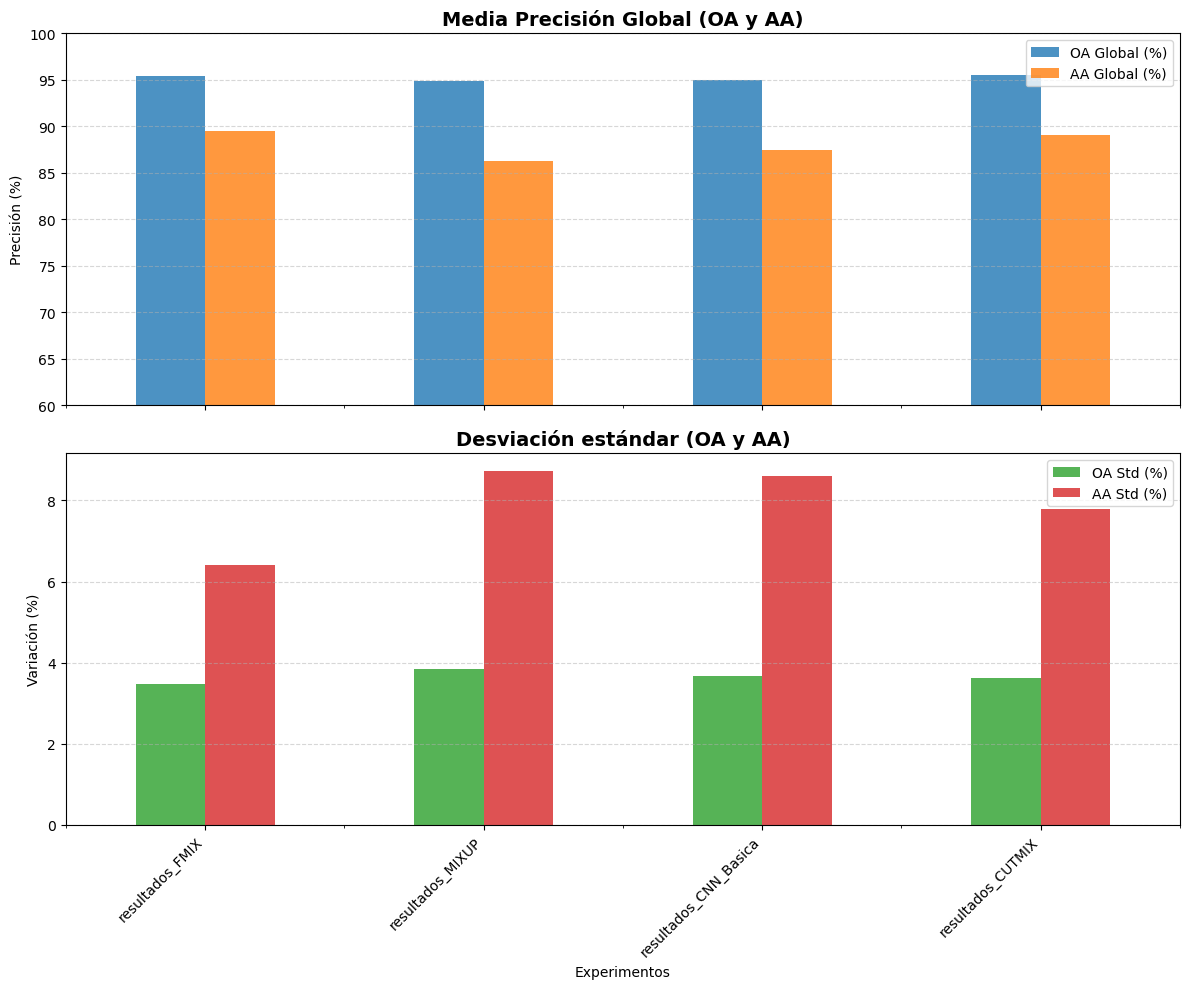

In [7]:
graficaComparacionModelos(datos_comparacion)

## Resultados usando el aumentado de la clase minoritaria en el dataloader

In [8]:
ruta_carpeta = "Codigos_AumentadoClaseMinoritaria/resultadosPruebas"

datos_comparacion=imprimirResultados(ruta_carpeta)


============================== ARCHIVO: resultados_FMIX ==============================

************* TABLA RESUMEN (OA/AA): *************
        Dataset  OA (%)  std OA (%)  AA (%)  std AA (%)
        oitaven   95.88        0.13   92.72        0.75
     das_mestas   91.25        0.21   89.38        0.20
      eiras_dam   97.17        0.13   93.23        0.74
  ermidas_creek   98.54        0.11   96.93        0.32
ferreiras_river   91.67        0.04   78.63        1.09
     mera_river   90.81        0.14   80.27        2.31
           ulla   99.02        0.51   98.07        1.29
          xesta   98.43        0.06   93.80        0.50

************* ACCURACY POR CLASE POR DATASET: *************
Clase           Clase 01  Clase 02 Clase 03 Clase 04 Clase 05 Clase 06  Clase 07  Clase 08 Clase 09 Clase 10
Dataset                                                                                                     
das_mestas             -     73.50        -        -        -        -     91

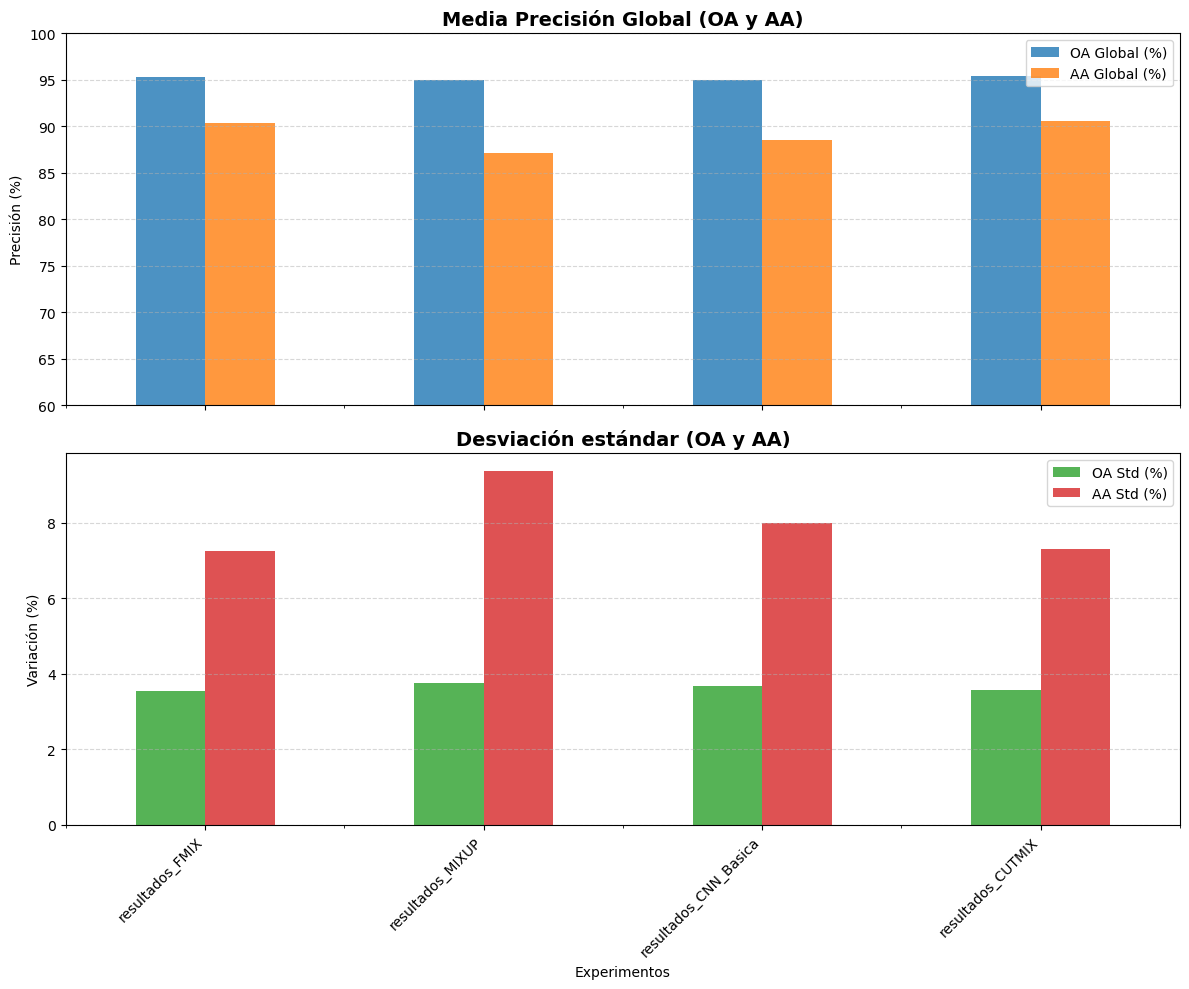

In [9]:
graficaComparacionModelos(datos_comparacion)

## Comparación de cada versión


==================== COMPARANDO: resultados_MIXUP ====================
Versión                           | OA Global (%)     | AA Global (%)
----------------------------------|-------------------|-------------------
Aumentado                         | 94.98 ± 3.77      | 87.09 ± 9.38
Sin Aumentado Clase Minoritaria   | 94.84 ± 3.85      | 86.27 ± 8.73

==================== COMPARANDO: resultados_FMIX ====================
Versión                           | OA Global (%)     | AA Global (%)
----------------------------------|-------------------|-------------------
Aumentado                         | 95.35 ± 3.54      | 90.38 ± 7.26
Sin Aumentado Clase Minoritaria   | 95.42 ± 3.47      | 89.47 ± 6.41

==================== COMPARANDO: resultados_CNN_Basica ====================
Versión                           | OA Global (%)     | AA Global (%)
----------------------------------|-------------------|-------------------
Aumentado                         | 95.01 ± 3.68      | 88.47 ± 7.99


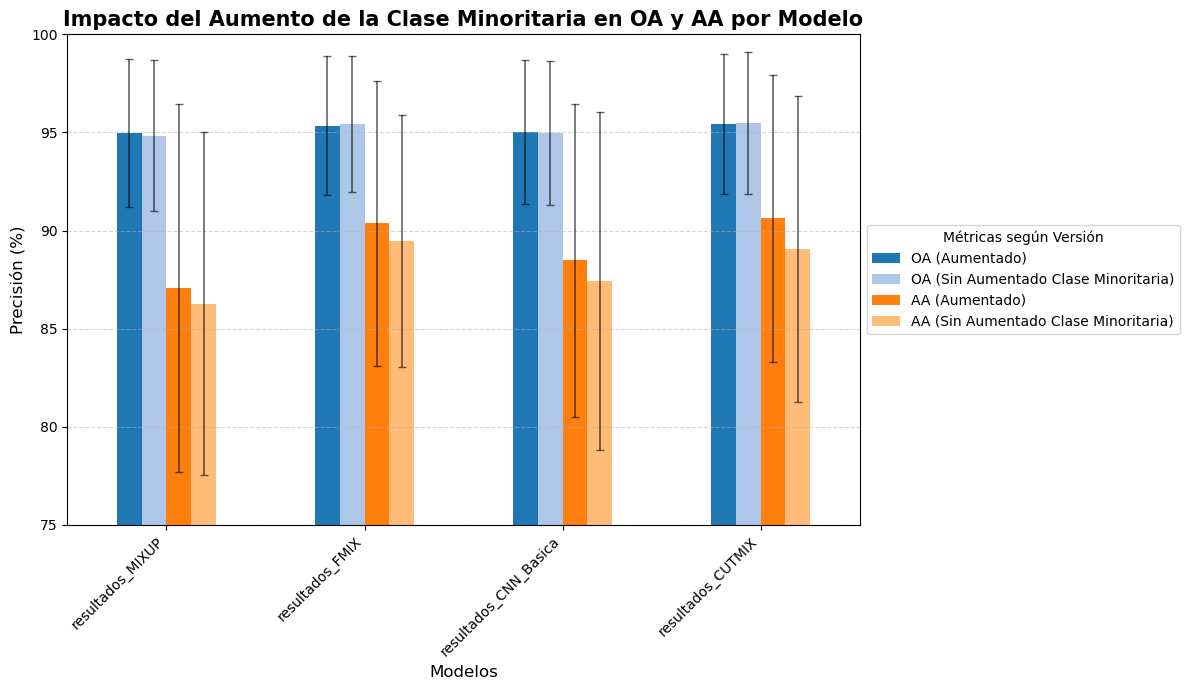

In [ ]:
import re
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

def procesar_log_detallado(ruta_archivo):
    # (La función de extracción se mantiene igual)
    try:
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            texto = f.read()
    except FileNotFoundError:
        return f"Error: No se encontró el archivo {ruta_archivo}", None, None

    secciones = re.split(r"\*{20,}Ejecutando prueba sobre el dataset", texto)
    resumen_data = []
    clases_data = []
    
    for seccion in secciones[1:]:
        lineas = seccion.strip().split('\n')
        dataset_name = lineas[0].split('*')[0].strip()
        
        oa_match = re.search(r"OA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        aa_match = re.search(r"AA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        
        if oa_match and aa_match:
            resumen_data.append({
                "Dataset": dataset_name,
                "OA (%)": float(oa_match.group(1)),
                "AA (%)": float(aa_match.group(1))
            })
            
        bloque_clases = re.search(r"ACCURACY POR CLASE:(.*?)---", seccion, re.DOTALL)
        if bloque_clases:
            matches_clase = re.findall(r"Clase (\d+):\s*([\d.]+)%", bloque_clases.group(1))
            for num_clase, valor_acc in matches_clase:
                clases_data.append({
                    "Dataset": dataset_name,
                    "Clase": f"Clase {num_clase}",
                    "Accuracy (%)": float(valor_acc)
                })

    if not resumen_data:
        return None, None, None

    df_resumen = pd.DataFrame(resumen_data)
    df_clases_long = pd.DataFrame(clases_data)
    df_clases_wide = df_clases_long.pivot(index='Dataset', columns='Clase', values='Accuracy (%)')
    
    stats = {
        "Métrica": ["OA Global", "AA Global"],
        "Media (%)": [df_resumen["OA (%)"].mean(), df_resumen["AA (%)"].mean()],
        "Desviación (%)": [df_resumen["OA (%)"].std(), df_resumen["AA (%)"].std()]
    }
    df_stats = pd.DataFrame(stats)
    
    return df_resumen, df_stats, df_clases_wide


carpeta_v1 = "Codigos_AumentadoClaseMinoritaria/resultadosPruebas" # Con aumentado (Aumentado)
carpeta_v2 = "Codigos_no_clase_minoritaria/resultadosPruebas" # Sin aumentado

# Obtenemos solo los nombres de archivo para buscar coincidencias
archivos_v1 = {os.path.basename(f) for f in glob.glob(os.path.join(carpeta_v1, "*.log"))}
archivos_v2 = {os.path.basename(f) for f in glob.glob(os.path.join(carpeta_v2, "*.log"))}

# Intersección: Solo analizamos los logs que existen en ambas carpetas
archivos_comunes = list(archivos_v1.intersection(archivos_v2))
datos_comparacion = []

if not archivos_comunes:
    print("No se encontraron archivos .log coincidentes entre ambas carpetas.")
else:
    for archivo_nombre in archivos_comunes:
        nombre_prueba = archivo_nombre.replace(".log", "")
        ruta_v1 = os.path.join(carpeta_v1, archivo_nombre)
        ruta_v2 = os.path.join(carpeta_v2, archivo_nombre)
        
        # Procesamos ambos archivos
        _, df_st_v1, _ = procesar_log_detallado(ruta_v1)
        _, df_st_v2, _ = procesar_log_detallado(ruta_v2)
        
        if df_st_v1 is not None and df_st_v2 is not None:
            # Extraemos datos V1 (Aumentado)
            oa_v1 = df_st_v1.loc[df_st_v1['Métrica'] == 'OA Global', 'Media (%)'].values[0]
            aa_v1 = df_st_v1.loc[df_st_v1['Métrica'] == 'AA Global', 'Media (%)'].values[0]
            oa_std_v1 = df_st_v1.loc[df_st_v1['Métrica'] == 'OA Global', 'Desviación (%)'].values[0]
            aa_std_v1 = df_st_v1.loc[df_st_v1['Métrica'] == 'AA Global', 'Desviación (%)'].values[0]
            
            # Extraemos datos V2 (Sin Aumentado)
            oa_v2 = df_st_v2.loc[df_st_v2['Métrica'] == 'OA Global', 'Media (%)'].values[0]
            aa_v2 = df_st_v2.loc[df_st_v2['Métrica'] == 'AA Global', 'Media (%)'].values[0]
            oa_std_v2 = df_st_v2.loc[df_st_v2['Métrica'] == 'OA Global', 'Desviación (%)'].values[0]
            aa_std_v2 = df_st_v2.loc[df_st_v2['Métrica'] == 'AA Global', 'Desviación (%)'].values[0]
            
            # Imprimimos comparación uno a uno en consola con anchos ajustados
            print(f"\n{'='*20} COMPARANDO: {nombre_prueba} {'='*20}")
            print(f"Versión                           | OA Global (%)     | AA Global (%)")
            print(f"----------------------------------|-------------------|-------------------")
            print(f"Aumentado                         | {oa_v1:5.2f} ± {oa_std_v1:4.2f}      | {aa_v1:5.2f} ± {aa_std_v1:4.2f}")
            print(f"Sin Aumentado Clase Minoritaria   | {oa_v2:5.2f} ± {oa_std_v2:4.2f}      | {aa_v2:5.2f} ± {aa_std_v2:4.2f}")
            
            # Guardamos para el DataFrame final
            datos_comparacion.append({
                "Prueba": nombre_prueba,
                "OA_Orig": oa_v1, "OA_SinAum": oa_v2,
                "AA_Orig": aa_v1, "AA_SinAum": aa_v2,
                "OA_Std_Orig": oa_std_v1, "OA_Std_SinAum": oa_std_v2,
                "AA_Std_Orig": aa_std_v1, "AA_Std_SinAum": aa_std_v2
            })

#  GRÁFICA Y TABLA COMPARATIVA GLOBAL
if datos_comparacion:
    df_comp = pd.DataFrame(datos_comparacion)
    
    print("\n\n" + "="*80)
    print("=== TABLA RESUMEN GLOBAL DE COMPARACIÓN ===")
    print("="*80)
    # Mostramos una versión simplificada de la tabla
    df_mostrar = df_comp[['Prueba', 'OA_Orig', 'OA_SinAum', 'AA_Orig', 'AA_SinAum']].copy()
    df_mostrar.columns = ['Prueba', 'OA (Aumentado)', 'OA (Sin Aumentado Clase Minoritaria)', 'AA (Aumentado)', 'AA (Sin Aumentado Clase Minoritaria)']
    print(df_mostrar.to_string(index=False))
    
    # Preparamos los DataFrames para graficar
    df_medias = df_comp[['Prueba', 'OA_Orig', 'OA_SinAum', 'AA_Orig', 'AA_SinAum']].set_index('Prueba')
    df_errores = df_comp[['Prueba', 'OA_Std_Orig', 'OA_Std_SinAum', 'AA_Std_Orig', 'AA_Std_SinAum']].set_index('Prueba')
    
    # Actualizamos los nombres para la leyenda de la gráfica
    columnas_limpias = [
        'OA (Aumentado)', 
        'OA (Sin Aumentado Clase Minoritaria)', 
        'AA (Aumentado)', 
        'AA (Sin Aumentado Clase Minoritaria)'
    ]
    df_medias.columns = columnas_limpias
    df_errores.columns = columnas_limpias
    
    # Colores
    colores = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78']
    
    # Graficar
    df_medias.plot(
        kind='bar', 
        yerr=df_errores,
        capsize=3,
        error_kw={'alpha': 0.6, 'lw': 1.2},
        figsize=(12, 7), 
        color=colores
    )
    
    plt.title('Impacto del Aumento de la Clase Minoritaria en OA y AA por Modelo', fontsize=15, fontweight='bold')
    plt.xlabel('Modelos', fontsize=12)
    plt.ylabel('Precisión (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(75, 100)
    # Movemos un poco la leyenda para que el texto largo no tape las barras
    plt.legend(title='Métricas según Versión', loc='center left', bbox_to_anchor=(1, 0.5))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

CutMix y FMIX son los que mejores resultados dan en ambos casos.
MixUp obtiene peores resultados en ambos casos.

Usar la repetición ayuda a subir mucho el accuracy en clases poco representadas, este ocurre en la clase 6 del dataset eiras_dam (que representa el 0.2% del dataset), donde FMIX pasa del 86.64% de acierto al 99.71% de acierto, CutMix pasa del 89.51% al 96.15%.

Esto también ocurre en el dataset mera_river con la clase 5 (0.01% del dataset), donde usar FMIX o CutMix aumenta el accuracy a casi el doble sobre la cnn básica sin aumentado de datos.

Existen casos donde hay clases muy poco representadas, como la clase 9 en ferreiras_river, donde representa el 0.02% del dataset, en este caso la red no logra sacar patrones para reconocer esta clase debido a que existen muy pocos píxeles de la misma.

